In [3]:
import pandas as pd

# Load the ECG dataset
DATA_PATH = "ECG dataset.csv"
df = pd.read_csv(DATA_PATH)

# Display basic dataset information
print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (441, 2501)


,0,1,2,3,4,5,6,7,8,9,...,2491,2492,2493,2494,2495,2496,2497,2498,2499,Target
0,0.012976,0.022008,0.049401,0.007309,0.080700,0.084465,0.053040,0.110527,0.147975,0.158048,...,-0.086520,-0.076036,-0.073070,-0.075017,-0.077458,-0.051301,-0.029699,-0.044448,0.015390,Sleep Apnea
1,0.007665,0.011024,0.014001,0.115614,0.045236,0.053854,0.144119,0.093378,0.178889,0.133928,...,-0.590053,-0.585818,-0.504592,-0.412495,-0.410130,-0.247508,-0.543017,-0.138173,-0.020498,Normal
2,0.044957,0.028612,0.085881,0.018910,0.078694,0.103297,0.046348,0.148435,0.148251,0.140560,...,-0.663029,-0.596072,-0.501529,-0.432133,-0.396986,-0.308740,-0.195283,-0.085512,0.001185,Normal
3,-0.011676,0.027831,0.029627,0.021658,0.068194,0.075705,0.095863,0.123471,0.155526,0.150709,...,-0.085069,-0.117560,-0.108299,-0.083278,-0.067660,-0.010860,-0.030781,-0.007939,0.019734,Sleep Apnea
4,-0.008188,0.001010,-0.009165,0.061274,0.087704,0.055419,0.120823,0.107706,0.133526,0.166235,...,-0.114268,-0.061457,-0.097293,-0.085431,-0.065468,-0.049709,-0.013976,-0.011729,0.014483,Sleep Apnea


In [5]:
print(df.shape)
print(df.columns)

print("\nTarget Value Counts:")
print(df["Target"].value_counts(dropna=False))

print("\nUnique Target Labels:")
print(df["Target"].unique())

(441, 2501)
Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '2491', '2492', '2493', '2494', '2495', '2496', '2497', '2498', '2499',
       'Target'],
      dtype='object', length=2501)

Target Value Counts:
Target
Sleep Apnea    229
Normal         211
NaN              1
Name: count, dtype: int64

Unique Target Labels:
['Sleep Apnea' 'Normal' nan]


In [6]:
df = df.dropna(subset=["Target"]).reset_index(drop=True)

print(df["Target"].value_counts(dropna=False))

Target
Sleep Apnea    229
Normal         211
Name: count, dtype: int64


In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ============================================================
# Separate Features and Target
# ============================================================
X = df.drop(columns=["Target"]).values
y = df["Target"].values

# ============================================================
# Encode Target Labels
# ============================================================
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Display label mapping
class_mapping = {
    label: int(code)
    for label, code in zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
}

# ============================================================
# Split Dataset
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# Feature Scaling
# ============================================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# Reshape for CNN
# ============================================================
TIMESTEPS = X_train.shape[1]

X_train = X_train.reshape(-1, TIMESTEPS, 1)
X_test = X_test.reshape(-1, TIMESTEPS, 1)

# ============================================================
# Display Dataset Information
# ============================================================
print("=" * 50)
print("Data Preprocessing Completed")
print("=" * 50)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")
print(f"Input Shape      : {X_train.shape[1:]}")

print("\nClass Labels:")
print(class_mapping)

Data Preprocessing Completed
Training Samples : 352
Testing Samples  : 88
Input Shape      : (2500, 1)

Class Labels:
{'Normal': 0, 'Sleep Apnea': 1}


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)
from tensorflow.keras.regularizers import l2

# ============================================================
# Build 1D CNN Model
# ============================================================

model = Sequential([

    # Input Layer
    Input(shape=(TIMESTEPS, 1)),

    # Convolution Block 1
    Conv1D(
        filters=32,
        kernel_size=5,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    MaxPooling1D(pool_size=2),

    # Convolution Block 2
    Conv1D(
        filters=64,
        kernel_size=5,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    MaxPooling1D(pool_size=2),

    # Convolution Block 3
    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    MaxPooling1D(pool_size=2),

    # Global Feature Pooling
    GlobalAveragePooling1D(),

    # Fully Connected Layer
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),

    # Dropout for Regularization
    Dropout(0.5),

    # Output Layer
    Dense(
        1,
        activation="sigmoid"
    )
])

# ============================================================
# Compile Model
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ============================================================
# Display Model Summary
# ============================================================

print("=" * 60)
print("ECG Sleep Apnea Detection - CNN Architecture")
print("=" * 60)

model.summary()

ECG Sleep Apnea Detection - CNN Architecture


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 2496, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 1248, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 1244, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 622, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 618, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 309, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,225 (266.50 KB)

 Trainable params: 68,225 (266.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# ============================================================
# Training Callbacks
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath="best_ecg_sleep_apnea_model.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

# ============================================================
# Train the Model
# ============================================================

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[
        early_stopping,
        model_checkpoint,
        reduce_lr
    ],
    shuffle=True,
    verbose=1
)

print("\n" + "=" * 60)
print("Training Completed Successfully")
print("=" * 60)

Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.8816 - loss: 0.4247
Epoch 1: val_loss improved from None to 0.27319, saving model to best_ecg_sleep_apnea_model.keras

Epoch 1: finished saving model to best_ecg_sleep_apnea_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 311ms/step - accuracy: 0.8977 - loss: 0.3963 - val_accuracy: 0.9545 - val_loss: 0.2732 - learning_rate: 0.0010
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.9199 - loss: 0.3496
Epoch 2: val_loss did not improve from 0.27319
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 275ms/step - accuracy: 0.8977 - loss: 0.4095 - val_accuracy: 0.9545 - val_loss: 0.2794 - learning_rate: 0.0010
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9000 - loss: 0.3960
Epoch 3: val_loss did not improve from 0.27319
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 0.8977 - loss: 0.4074 - val_accuracy: 0.9545 - val_loss: 0.2831 - learning_rate: 0.0010
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accur

In [16]:
# ============================================================
# Evaluate Model on Test Dataset
# ============================================================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("=" * 60)
print("Model Evaluation on Test Dataset")
print("=" * 60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4%}")

Model Evaluation on Test Dataset
Test Loss     : 0.2590
Test Accuracy : 95.4545%


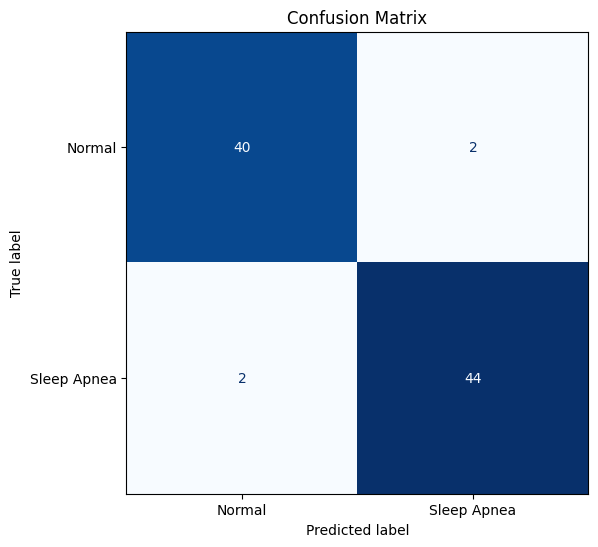

Classification Report
              precision    recall  f1-score   support

      Normal     0.9524    0.9524    0.9524        42
 Sleep Apnea     0.9565    0.9565    0.9565        46

    accuracy                         0.9545        88
   macro avg     0.9545    0.9545    0.9545        88
weighted avg     0.9545    0.9545    0.9545        88



In [17]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ============================================================
# Generate Predictions
# ============================================================

y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

# ============================================================
# Classification Report
# ============================================================

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        digits=4
    )
)

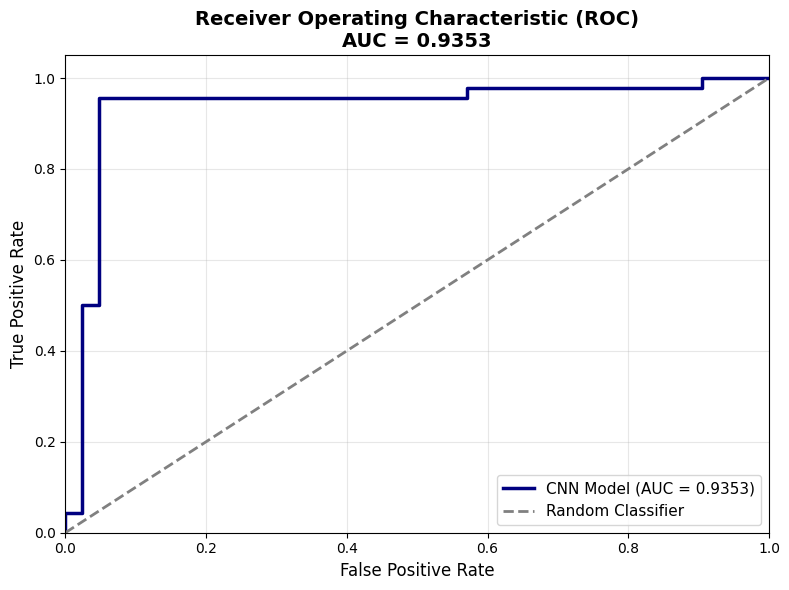

ROC Analysis
AUC Score : 0.9353


In [19]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

# ============================================================
# ROC Curve and Area Under the Curve (AUC)
# ============================================================

# Predict probabilities for the positive class
y_pred_prob = model.predict(X_test, verbose=0).ravel()

# Compute ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

# ============================================================
# Plot ROC Curve
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    color="navy",
    linewidth=2.5,
    label=f"CNN Model (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    color="gray",
    label="Random Classifier"
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title(
    f"Receiver Operating Characteristic (ROC)\nAUC = {auc_score:.4f}",
    fontsize=14,
    fontweight="bold"
)

plt.grid(alpha=0.30)
plt.legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()

# ============================================================
# Display AUC Score
# ============================================================

print("=" * 60)
print("ROC Analysis")
print("=" * 60)
print(f"AUC Score : {auc_score:.4f}")

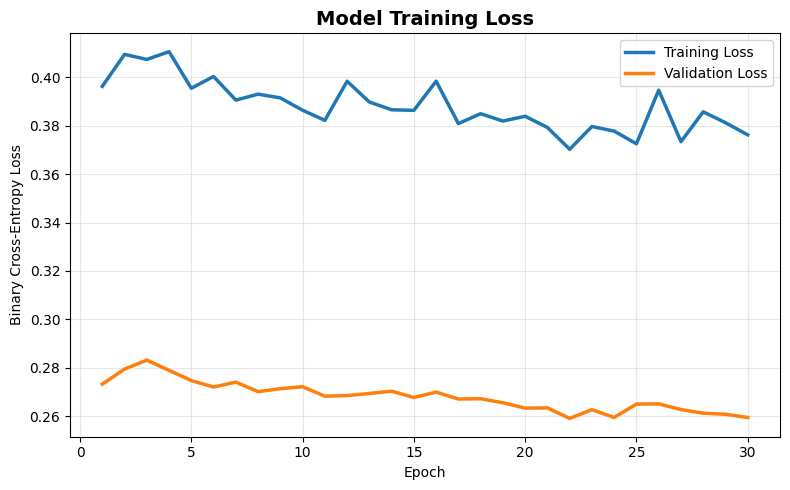

In [22]:
import matplotlib.pyplot as plt

# ============================================================
# Model Training Loss
# ============================================================

history_dict = history.history

train_loss = history_dict["loss"]
val_loss = history_dict["val_loss"]

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_loss,
    linewidth=2.5,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    linewidth=2.5,
    label="Validation Loss"
)

plt.title("Model Training Loss", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.grid(alpha=0.30)
plt.legend()

plt.tight_layout()
plt.show()